# Introduction to the Uber Dataset

In [69]:
import pandas as pd # Import thư viện pandas để xử lý dữ liệu dạng bảng

uber_data = pd.read_csv("uber-raw-data-jul14.csv") # Đọc file CSV chứa dữ liệu Uber tháng 7/2014

print(uber_data.tail(10)) # Hiển thị 10 dòng cuối của dữ liệu

uber_data.info() # Xem thông tin tổng quan: số dòng, số cột, kiểu dữ liệu, giá trị null


                 Date/Time      Lat      Lon    Base
796111  7/31/2014 22:53:00  40.6262 -73.9448  B02764
796112  7/31/2014 22:54:00  40.7617 -73.9650  B02764
796113  7/31/2014 22:56:00  40.7049 -73.9337  B02764
796114  7/31/2014 23:05:00  40.7483 -74.0040  B02764
796115  7/31/2014 23:06:00  40.7332 -73.9934  B02764
796116  7/31/2014 23:22:00  40.7285 -73.9846  B02764
796117  7/31/2014 23:23:00  40.7615 -73.9868  B02764
796118  7/31/2014 23:29:00  40.6770 -73.9515  B02764
796119  7/31/2014 23:30:00  40.7225 -74.0038  B02764
796120  7/31/2014 23:58:00  40.7199 -73.9884  B02764
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 796121 entries, 0 to 796120
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  796121 non-null  object 
 1   Lat        796121 non-null  float64
 2   Lon        796121 non-null  float64
 3   Base       796121 non-null  object 
dtypes: float64(2), object(2)
memory usage: 24.3+ MB


In [70]:
uber_data["Date/Time"] = pd.to_datetime(uber_data["Date/Time"]) # Chuyển cột "Date/Time" từ chuỗi sang kiểu thời gian (datetime)


In [71]:
print(uber_data["Date/Time"].dt.floor('1h').tail(10)) # Làm tròn thời gian xuống mốc giờ gần nhất (theo 1 giờ) và in 10 giá trị cuối

796111   2014-07-31 22:00:00
796112   2014-07-31 22:00:00
796113   2014-07-31 22:00:00
796114   2014-07-31 23:00:00
796115   2014-07-31 23:00:00
796116   2014-07-31 23:00:00
796117   2014-07-31 23:00:00
796118   2014-07-31 23:00:00
796119   2014-07-31 23:00:00
796120   2014-07-31 23:00:00
Name: Date/Time, dtype: datetime64[ns]


In [72]:
print(uber_data["Date/Time"].dt.floor('1h').value_counts().head(10))
# Đếm số chuyến theo từng mốc giờ (làm tròn xuống 1 giờ)
# Hiển thị 10 mốc giờ có số chuyến nhiều nhất

Date/Time
2014-07-15 18:00:00    3302
2014-07-15 19:00:00    3225
2014-07-15 17:00:00    3045
2014-07-02 18:00:00    2946
2014-07-15 20:00:00    2840
2014-07-23 20:00:00    2791
2014-07-23 21:00:00    2559
2014-07-31 18:00:00    2531
2014-07-23 17:00:00    2519
2014-07-02 17:00:00    2479
Name: count, dtype: int64


In [73]:
# Làm tròn thời gian về từng giờ (ví dụ 08:23 → 08:00),
# sau đó đếm số chuyến ở mỗi mốc giờ
hourly_data = uber_data["Date/Time"].dt.floor('1h').value_counts()

# Sắp xếp lại theo thứ tự thời gian tăng dần (chronological)
hourly_data = hourly_data.sort_index()

# In ra 10 mốc giờ đầu tiên
print(hourly_data.head(10))

Date/Time
2014-07-01 00:00:00     216
2014-07-01 01:00:00     111
2014-07-01 02:00:00      82
2014-07-01 03:00:00     134
2014-07-01 04:00:00     223
2014-07-01 05:00:00     348
2014-07-01 06:00:00     715
2014-07-01 07:00:00    1196
2014-07-01 08:00:00    1076
2014-07-01 09:00:00     885
Name: count, dtype: int64


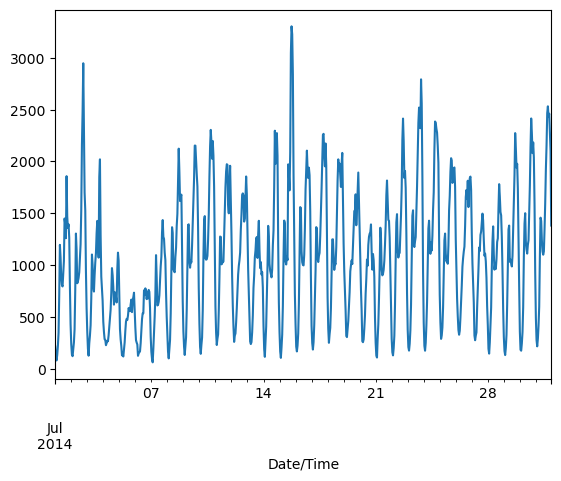

In [74]:
import matplotlib.pyplot as plt   # Thư viện dùng để vẽ biểu đồ

# Vẽ biểu đồ đường để quan sát xu hướng số chuyến theo thời gian
hourly_data.plot(kind="line")

plt.show()  # Hiển thị biểu đồ

In [75]:
# Tách thời gian thành giờ trong ngày
hours = uber_data["Date/Time"].dt.hour

# Tách thứ trong tuần (0 = Thứ Hai, 6 = Chủ Nhật)
week_day = uber_data["Date/Time"].dt.weekday

# Tách phần ngày (YYYY-MM-DD)
date = uber_data["Date/Time"].dt.date

# Ghép 3 cột lại thành một DataFrame mới
weekly_data = pd.concat([week_day, hours, date], axis=1)

# Đặt tên cho các cột
weekly_data.columns = ["Week Day", "Hour", "Date"]

# In ra thứ trong tuần của dòng thứ 66003 (để kiểm tra)
print(week_day.iloc[66003])

# In ra 10 dòng cuối của DataFrame mới
print(weekly_data.tail(10))

5
        Week Day  Hour        Date
796111         3    22  2014-07-31
796112         3    22  2014-07-31
796113         3    22  2014-07-31
796114         3    23  2014-07-31
796115         3    23  2014-07-31
796116         3    23  2014-07-31
796117         3    23  2014-07-31
796118         3    23  2014-07-31
796119         3    23  2014-07-31
796120         3    23  2014-07-31


In [76]:
import calendar   # Thư viện làm việc với lịch, ngày tháng

# calendar.day_name ánh xạ số thứ trong tuần → tên thứ
# 0 = Monday, 1 = Tuesday, ..., 6 = Sunday
print(calendar.day_name[6])  # In ra tên của ngày có chỉ số 6 (Sunday)

Sunday


In [77]:
# Chuyển cột Week Day từ số (0–6) sang tên thứ (Monday, Tuesday, ...)
weekly_data["Week Day"] = weekly_data["Week Day"].apply(
    lambda x: calendar.day_name[x]
)

# In ra tên thứ của dòng thứ 66003 để kiểm tra
print(weekly_data["Week Day"].iloc[66003])

Saturday


In [78]:
# Gom nhóm dữ liệu theo Date, Week Day và Hour,
# sau đó đếm số bản ghi (số chuyến) trong mỗi nhóm
weekly_data = weekly_data.groupby(
    ["Date", "Week Day", "Hour"]
).size()

# In ra 10 dòng đầu để kiểm tra kết quả
print(weekly_data.head(10))

Date        Week Day  Hour
2014-07-01  Tuesday   0        216
                      1        111
                      2         82
                      3        134
                      4        223
                      5        348
                      6        715
                      7       1196
                      8       1076
                      9        885
dtype: int64


In [79]:
# Đưa các mức index (Date, Week Day, Hour) trở lại thành cột bình thường
weekly_data = weekly_data.reset_index()

# In ra 10 dòng đầu để kiểm tra
print(weekly_data.head(10))

         Date Week Day  Hour     0
0  2014-07-01  Tuesday     0   216
1  2014-07-01  Tuesday     1   111
2  2014-07-01  Tuesday     2    82
3  2014-07-01  Tuesday     3   134
4  2014-07-01  Tuesday     4   223
5  2014-07-01  Tuesday     5   348
6  2014-07-01  Tuesday     6   715
7  2014-07-01  Tuesday     7  1196
8  2014-07-01  Tuesday     8  1076
9  2014-07-01  Tuesday     9   885


In [80]:
# Đổi tên cột mặc định "0" (kết quả của size()) thành "Size"
weekly_data = weekly_data.rename(columns={0: "Size"})

# In ra 10 dòng đầu để kiểm tra
print(weekly_data.head(10))

         Date Week Day  Hour  Size
0  2014-07-01  Tuesday     0   216
1  2014-07-01  Tuesday     1   111
2  2014-07-01  Tuesday     2    82
3  2014-07-01  Tuesday     3   134
4  2014-07-01  Tuesday     4   223
5  2014-07-01  Tuesday     5   348
6  2014-07-01  Tuesday     6   715
7  2014-07-01  Tuesday     7  1196
8  2014-07-01  Tuesday     8  1076
9  2014-07-01  Tuesday     9   885


In [81]:
# Gom nhóm theo thứ trong tuần và giờ,
# rồi tính trung bình số chuyến (Size) cho mỗi cặp thứ/giờ
weekly_data = weekly_data.groupby(
    ["Week Day", "Hour"]
)["Size"].mean()

# In ra 10 dòng đầu để kiểm tra
print(weekly_data.head(10))

Week Day  Hour
Friday    0        615.00
          1        385.25
          2        264.75
          3        307.50
          4        339.75
          5        497.25
          6        736.75
          7       1008.00
          8       1038.00
          9        907.75
Name: Size, dtype: float64


In [82]:
# unstack() lấy một level của MultiIndex và chuyển nó thành cột
# level=0 tương ứng với "Week Day" → mỗi thứ sẽ là một cột
weekly_data = weekly_data.unstack(level=0)

# In ra toàn bộ bảng sau khi unstack
print(weekly_data)

Week Day   Friday   Monday  Saturday   Sunday  Thursday  Tuesday  Wednesday
Hour                                                                       
0          615.00   315.00   1110.25  1090.00     430.0    301.8      354.6
1          385.25   153.25    788.25   829.50     231.4    155.8      193.2
2          264.75   109.75    580.00   638.25     171.0    111.2      156.0
3          307.50   254.75    426.00   477.00     256.6    187.0      224.0
4          339.75   403.75    271.75   245.50     376.8    296.6      326.0
5          497.25   615.25    274.25   231.25     586.2    546.0      559.8
6          736.75   911.00    303.50   256.75     959.2    962.2     1003.4
7         1008.00  1266.50    398.50   316.25    1341.8   1350.0     1425.8
8         1038.00  1199.25    525.25   466.75    1336.6   1332.4     1425.0
9          907.75   923.00    667.00   657.50    1077.0   1012.2     1083.8
10         875.75   855.75    823.25   801.25    1014.2    977.4     1035.2
11         9

In [83]:
# Sắp xếp lại thứ tự các cột theo đúng thứ trong tuần
weekly_data = weekly_data.reindex(
    columns=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

# In ra bảng sau khi sắp xếp lại cột
print(weekly_data)

Week Day   Monday  Tuesday  Wednesday  Thursday   Friday  Saturday   Sunday
Hour                                                                       
0          315.00    301.8      354.6     430.0   615.00   1110.25  1090.00
1          153.25    155.8      193.2     231.4   385.25    788.25   829.50
2          109.75    111.2      156.0     171.0   264.75    580.00   638.25
3          254.75    187.0      224.0     256.6   307.50    426.00   477.00
4          403.75    296.6      326.0     376.8   339.75    271.75   245.50
5          615.25    546.0      559.8     586.2   497.25    274.25   231.25
6          911.00    962.2     1003.4     959.2   736.75    303.50   256.75
7         1266.50   1350.0     1425.8    1341.8  1008.00    398.50   316.25
8         1199.25   1332.4     1425.0    1336.6  1038.00    525.25   466.75
9          923.00   1012.2     1083.8    1077.0   907.75    667.00   657.50
10         855.75    977.4     1035.2    1014.2   875.75    823.25   801.25
11         8

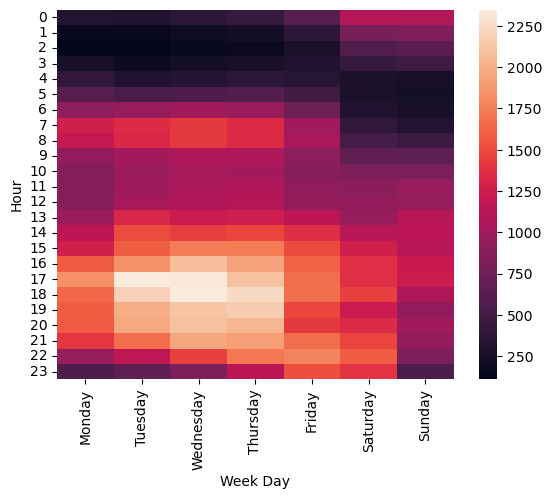

In [84]:
import seaborn as sns   # Thư viện trực quan hóa dữ liệu, đẹp và gọn hơn matplotlib

# Vẽ heatmap (bản đồ nhiệt) từ bảng weekly_data
sns.heatmap(weekly_data)

plt.show()  # Hiển thị biểu đồ

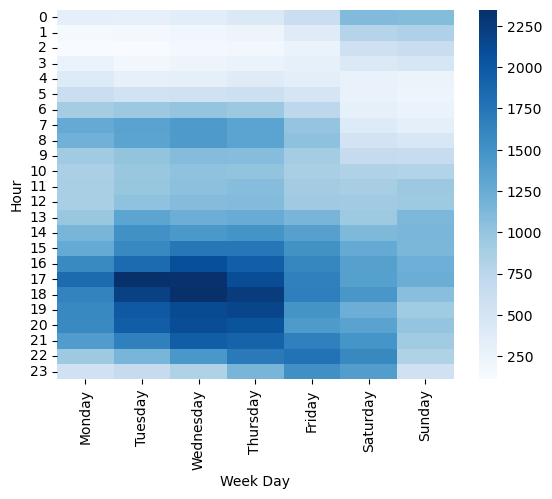

In [85]:
# Vẽ heatmap và đổi bảng màu sang tông xanh (Blues)
sns.heatmap(weekly_data, cmap='Blues')

plt.show()  # Hiển thị biểu đồ

# Points of Interest

In [86]:
# geopy là thư viện dùng để tính khoảng cách giữa các tọa độ (latitude, longitude)
%pip install geopy
# Cài đặt thư viện geopy trong môi trường hiện tại (Jupyter)

import geopy.distance
# Import module distance để tính khoảng cách địa lý (km, m, miles, ...)

Note: you may need to restart the kernel to use updated packages.


In [89]:
metro_art_coordinates = (40.7794, -73.9632) # Tọa độ Bảo tàng Metropolitan (vĩ độ, kinh độ)

empire_state_building_coordinates = (40.7484, -73.9857) # Tọa độ tòa nhà Empire State

distance = geopy.distance.distance(
    metro_art_coordinates,
    empire_state_building_coordinates
) # Tính khoảng cách địa lý giữa hai điểm

print(distance) # In khoảng cách (đơn vị mặc định: km)

print(distance.mi) # In khoảng cách theo đơn vị mile

3.9319431838516716 km
2.443196223959372


In [90]:
print(uber_data[["Lat", "Lon"]].apply(lambda x: tuple(x), axis=1)) # Gộp mỗi cặp (Lat, Lon) của từng dòng thành một tuple (latitude, longitude)

0         (40.7586, -73.9706)
1         (40.7605, -73.9994)
2          (40.732, -73.9999)
3         (40.7635, -73.9793)
4         (40.7204, -74.0047)
                 ...         
796116    (40.7285, -73.9846)
796117    (40.7615, -73.9868)
796118     (40.677, -73.9515)
796119    (40.7225, -74.0038)
796120    (40.7199, -73.9884)
Length: 796121, dtype: object


In [91]:
from math import radians, cos, sin, asin, sqrt # Import các hàm toán học cần thiết

def haversine(coordinates1, coordinates2):
    # Hàm tính khoảng cách giữa 2 điểm dựa trên công thức Haversine

    lon1 = coordinates1[1]
    lat1 = coordinates1[0]
    lon2 = coordinates2[1]
    lat2 = coordinates2[0]
    # Lấy kinh độ và vĩ độ từ tuple (lat, lon)

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2]) # Chuyển độ sang radian

    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 3956
    # r là bán kính Trái Đất (mile)

    return c * r
    # Trả về khoảng cách giữa 2 điểm (mile)

print(haversine(metro_art_coordinates, empire_state_building_coordinates)) # Khoảng cách tính bằng công thức Haversine

print(distance.mi) # Khoảng cách tính bằng geopy (để so sánh)


2.442501323483997
2.443196223959372


In [92]:
uber_data["Distance MM"] = uber_data[["Lat", "Lon"]].apply(
    lambda x: haversine(metro_art_coordinates, tuple(x)), axis=1
)
# Tính khoảng cách từ mỗi điểm Uber đến Bảo tàng Metropolitan (MM)

uber_data["Distance ESB"] = uber_data[["Lat", "Lon"]].apply(
    lambda x: haversine(empire_state_building_coordinates, tuple(x)), axis=1
)
# Tính khoảng cách từ mỗi điểm Uber đến tòa nhà Empire State (ESB)

print(uber_data["Distance MM"].head(5)) # In 5 giá trị khoảng cách đầu tiên đến MM

print(uber_data["Distance ESB"].head(5)) # In 5 giá trị khoảng cách đầu tiên đến ESB


0    1.487358
1    2.299140
2    3.794105
3    1.383450
4    4.615925
Name: Distance MM, dtype: float64
0    1.058178
1    1.100642
2    1.354266
3    1.094999
4    2.173858
Name: Distance ESB, dtype: float64


In [93]:
print(uber_data[["Distance MM", "Distance ESB"]].describe())
# Thống kê mô tả cho hai cột khoảng cách:
# count, mean, std, min, max, các quartile

         Distance MM   Distance ESB
count  796121.000000  796121.000000
mean        3.868244       2.723783
std         3.200848       3.276343
min         0.037592       0.000000
25%         1.863763       0.976621
50%         3.329218       1.726115
75%         4.691434       3.037256
max        86.770131      88.188585


In [94]:
print((uber_data[["Distance MM", "Distance ESB"]] < 0.25).sum())
# Đếm số chuyến Uber có khoảng cách < 0.25 mile
# đến Metropolitan Museum (MM) và Empire State Building (ESB)

Distance MM      2764
Distance ESB    15133
dtype: int64


In [95]:
import numpy as np # Import NumPy để làm việc với mảng số

distance_range = np.arange(0.1, 5.1, 0.1) # Tạo mảng khoảng cách từ 0.1 đến 5.0, bước 0.1

print(distance_range) # In mảng khoảng cách

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6
 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5 4.6 4.7 4.8 4.9 5. ]


In [96]:
distance_data = [
    (uber_data[["Distance MM", "Distance ESB"]] < dist).sum()
    for dist in distance_range
]
# Với mỗi giá trị dist, đếm số chuyến Uber có khoảng cách nhỏ hơn dist đến MM và ESB

print(distance_data) # In danh sách kết quả theo từng khoảng cách

[Distance MM      575
Distance ESB    2387
dtype: int64, Distance MM     1776
Distance ESB    9661
dtype: int64, Distance MM      4566
Distance ESB    22166
dtype: int64, Distance MM      8783
Distance ESB    42427
dtype: int64, Distance MM     13606
Distance ESB    68011
dtype: int64, Distance MM     20770
Distance ESB    92650
dtype: int64, Distance MM      29408
Distance ESB    119621
dtype: int64, Distance MM      38912
Distance ESB    147815
dtype: int64, Distance MM      50497
Distance ESB    177759
dtype: int64, Distance MM      63072
Distance ESB    206056
dtype: int64, Distance MM      75474
Distance ESB    240003
dtype: int64, Distance MM      89442
Distance ESB    277785
dtype: int64, Distance MM     105692
Distance ESB    311312
dtype: int64, Distance MM     123431
Distance ESB    335385
dtype: int64, Distance MM     141656
Distance ESB    355731
dtype: int64, Distance MM     157194
Distance ESB    375017
dtype: int64, Distance MM     174148
Distance ESB    393510
dtype: in

In [97]:
# Concat
distance_data = pd.concat(distance_data, axis=1) # Gộp danh sách các Series lại thành một DataFrame theo cột

print(distance_data) # In DataFrame sau khi ghép

                0     1      2      3      4      5       6       7       8   \
Distance MM    575  1776   4566   8783  13606  20770   29408   38912   50497   
Distance ESB  2387  9661  22166  42427  68011  92650  119621  147815  177759   

                  9   ...      40      41      42      43      44      45  \
Distance MM    63072  ...  512662  529702  546998  563198  575552  588588   
Distance ESB  206056  ...  656735  661066  665748  670373  674744  678522   

                  46      47      48      49  
Distance MM   597941  614256  621624  626604  
Distance ESB  682262  685487  688588  691884  

[2 rows x 50 columns]


In [98]:
# Transpose and add in the index
distance_data = distance_data.transpose() # Chuyển hàng ↔ cột để mỗi hàng ứng với một khoảng cách

distance_data.index = distance_range # Gán index là các giá trị khoảng cách đã xét

print(distance_data) # In kết quả cuối cùng

     Distance MM  Distance ESB
0.1          575          2387
0.2         1776          9661
0.3         4566         22166
0.4         8783         42427
0.5        13606         68011
0.6        20770         92650
0.7        29408        119621
0.8        38912        147815
0.9        50497        177759
1.0        63072        206056
1.1        75474        240003
1.2        89442        277785
1.3       105692        311312
1.4       123431        335385
1.5       141656        355731
1.6       157194        375017
1.7       174148        393510
1.8       190108        412560
1.9       204501        434040
2.0       219190        453986
2.1       234681        472681
2.2       250469        489396
2.3       265164        502460
2.4       276425        518076
2.5       291165        532569
2.6       306739        544541
2.7       318762        557718
2.8       329219        571684
2.9       341297        583354
3.0       354514        592929
3.1       369129        603990
3.2     

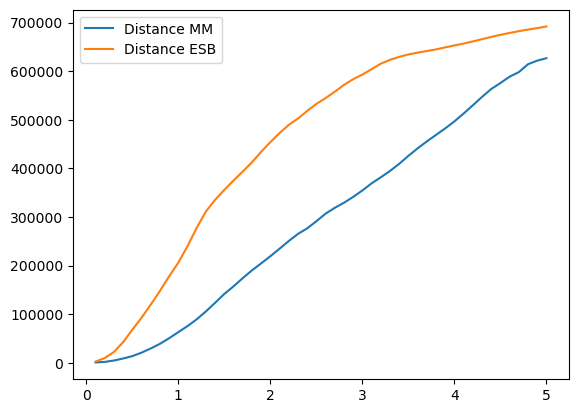

In [99]:
distance_data.plot(kind="line") # Vẽ biểu đồ đường thể hiện số chuyến Uber theo khoảng cách

plt.show() # Hiển thị biểu đồ

# Mapping Data with Folium

In [100]:
import folium  # Import thư viện folium để tạo và hiển thị bản đồ tương tác

uber_map = folium.Map(
    location=[10.827750345873257, 106.69999360890147],  # Tọa độ trung tâm bản đồ (vĩ độ, kinh độ) – Đại học Văn Lang CS3
    zoom_start=17  # Mức zoom ban đầu, số càng lớn thì zoom càng gần
)

folium.Marker(
    location=[10.827750345873257, 106.69999360890147],  # Vị trí đặt marker trên bản đồ
    popup="Đại học Văn Lang - Cơ sở 3",  # Nội dung hiển thị khi click vào marker
    tooltip="Văn Lang CS3",  # Chú thích hiện ra khi rê chuột vào marker
    icon=folium.Icon(color="red", icon="university", prefix="fa") # Tạo icon màu đỏ, hình trường đại học (Font Awesome)
).add_to(uber_map)  # Thêm marker vào bản đồ

uber_map  # Hiển thị bản đồ trong notebook

In [101]:
lat = uber_data["Lat"].values[:5]   # Lấy 5 giá trị vĩ độ (latitude) đầu tiên từ dữ liệu Uber
lon = uber_data["Lon"].values[:5]   # Lấy 5 giá trị kinh độ (longitude) đầu tiên

# Tạo bản đồ nền với tâm bản đồ tại tọa độ chỉ định
uber_map = folium.Map(
    location=[10.827489, 106.700059],  # Tọa độ trung tâm bản đồ (camera nhìn ban đầu)
    zoom_start=25                      # Mức zoom rất lớn → nhìn rất gần
)

# Duyệt qua 5 cặp tọa độ đã lấy
for i in range(len(lat)):
    folium.Marker(
        (lat[i], lon[i]),                 # Vị trí marker (vĩ độ, kinh độ)
        popup="Rider {}".format(i+1)      # Nội dung hiển thị khi click vào marker
    ).add_to(uber_map)                    # Gắn marker lên bản đồ

uber_map  # Hiển thị bản đồ trong notebook

In [102]:
from folium.plugins import HeatMap  # Import plugin HeatMap để vẽ bản đồ nhiệt (mật độ điểm)

lat_lon = uber_data[["Lat", "Lon"]].values[:10000]  # Lấy 10.000 cặp tọa độ (vĩ độ, kinh độ) từ dữ liệu Uber

uber_map = folium.Map(
    location=[40.7128, -74.0060],  
    # Tọa độ trung tâm bản đồ (New York)
    zoom_start=12  
    # Mức zoom ban đầu (xem toàn khu vực thành phố)
)

HeatMap(
    lat_lon,  
    # Dữ liệu tọa độ dùng để tạo heatmap
    radius=13  
    # Bán kính ảnh hưởng của mỗi điểm (càng lớn → vùng nhiệt càng rộng)
).add_to(uber_map)  
# Thêm lớp heatmap vào bản đồ

uber_map  # Hiển thị bản đồ heatmap

In [103]:
lat_lon = uber_data[["Lat", "Lon"]].values[:10000]  # Lấy 10.000 cặp tọa độ (vĩ độ, kinh độ) từ dữ liệu Uber

uber_map = folium.Map(
    location=[40.7128, -74.0060],  
    # Tọa độ trung tâm bản đồ (New York)
    zoom_start=10  
    # Zoom nhỏ hơn → quan sát được khu vực rộng hơn quanh thành phố
)

HeatMap(
    lat_lon,  
    # Dữ liệu tọa độ để vẽ heatmap
    radius=30  
    # Bán kính lớn → các điểm lan rộng, dễ thấy vùng mật độ ở xa trung tâm (vd: sân bay)
).add_to(uber_map)  
# Gắn heatmap vào bản đồ

uber_map  # Hiển thị bản đồ heatmap

In [104]:
uber_data["Weight"] = .5  # Tạo cột Weight và gán trọng số 0.5 cho mỗi điểm (điều chỉnh độ “nóng” của heatmap)

lat_lon = uber_data[["Lat", "Lon", "Weight"]].values[:10000]  # Lấy 10.000 điểm đầu tiên gồm: vĩ độ, kinh độ và trọng số

uber_map = folium.Map(
    location=[40.7128, -74.0060],  
    # Tọa độ trung tâm bản đồ (New York)
    zoom_start=12  
    # Mức zoom ban đầu để quan sát toàn thành phố
)

# Now let's increase radius since the weights are less
HeatMap(
    lat_lon,  
    # Dữ liệu heatmap có kèm trọng số
    radius=15  
    # Bán kính lan tỏa của mỗi điểm (tăng lên vì weight nhỏ)
).add_to(uber_map)  
# Thêm lớp heatmap vào bản đồ

uber_map  # Hiển thị bản đồ heatmap

In [112]:
# (Lọc các chuyến Uber nằm gần các địa điểm quan tâm)
# (Dùng ngưỡng 0.25 mile để tránh việc một điểm gần cả hai địa điểm cùng lúc)
i = uber_data[["Distance MM", "Distance ESB"]] < .25  
# So sánh từng giá trị khoảng cách:
# - True  → nếu khoảng cách < 0.25 mile
# - False → nếu khoảng cách ≥ 0.25 mile

print(i)  
# In ra DataFrame boolean (True/False) cho từng chuyến Uber
# Cột Distance MM và Distance ESB cho biết chuyến đó có gần địa điểm tương ứng hay không

        Distance MM  Distance ESB
0             False         False
1             False         False
2             False         False
3             False         False
4             False         False
...             ...           ...
796116        False         False
796117        False         False
796118        False         False
796119        False         False
796120        False         False

[796121 rows x 2 columns]


In [ ]:
i = i.any(axis=1)
# any(axis=1) kiểm tra theo từng hàng (row):
# - True  → nếu Distance MM < 0.25 HOẶC Distance ESB < 0.25
# - False → nếu cả hai đều >= 0.25

print(i) # In ra một Series boolean, mỗi phần tử ứng với 1 chuyến Uber

0         False
1         False
2         False
3         False
4         False
          ...  
796116    False
796117    False
796118    False
796119    False
796120    False
Length: 796121, dtype: bool


In [126]:
map_data = uber_data[i].copy()
# Lọc dữ liệu Uber:
# - i là Series boolean (True/False) theo từng hàng
# - Chỉ giữ những chuyến Uber có i == True
# - .copy() tạo bản sao độc lập để tránh warning khi chỉnh sửa sau này

print(map_data)
# In ra DataFrame mới:
# chỉ gồm các chuyến Uber gần Metropolitan Museum
# hoặc Empire State Building (trong phạm vi 0.25 mile)


                 Date/Time      Lat      Lon    Base  Distance MM  \
5      2014-07-01 00:35:00  40.7487 -73.9869  B02512     2.455439   
13     2014-07-01 02:07:00  40.7471 -73.9872  B02512     2.559080   
17     2014-07-01 03:20:00  40.7498 -73.9813  B02512     2.252287   
31     2014-07-01 05:22:00  40.7489 -73.9874  B02512     2.456893   
104    2014-07-01 07:39:00  40.7782 -73.9590  B02512     0.234702   
...                    ...      ...      ...     ...          ...   
795863 2014-07-31 13:02:00  40.7463 -73.9888  B02764     2.648655   
795910 2014-07-31 15:35:00  40.7460 -73.9864  B02764     2.605797   
795925 2014-07-31 16:05:00  40.7449 -73.9866  B02764     2.678014   
795940 2014-07-31 16:32:00  40.7501 -73.9825  B02764     2.260816   
796101 2014-07-31 22:29:00  40.7495 -73.9820  B02764     2.286599   

        Distance ESB  Weight           Date_Hour  
5           0.066098     0.5 2014-07-01 00:00:00  
13          0.119218     0.5 2014-07-01 02:00:00  
17          0.2496

In [127]:
# Let's draw on a heatmap with the locations within the radius
# (Vẽ heatmap cho các chuyến Uber nằm trong phạm vi đã lọc)

# Notice that one heatmap is a semi-circle because drop offs can't happen to the left of it
# (Heatmap có thể bị khuyết 1 phía vì khu vực đó không có điểm đón/trả xe – ví dụ là sông, công viên, hoặc khu cấm)

map_data["Weight"] = .1  
# Gán trọng số nhỏ (0.1) cho mỗi điểm để heatmap không quá đậm

lat_lon = map_data[["Lat", "Lon", "Weight"]].values  
# Lấy dữ liệu heatmap theo định dạng:
# [vĩ độ, kinh độ, trọng số]

uber_map = folium.Map(
    location=[40.7728, -74.0060],  
    zoom_start=13  
)

HeatMap(
    lat_lon,  
    # Dữ liệu heatmap
    radius=10  
    # Bán kính ảnh hưởng của mỗi điểm (nhỏ => heatmap chi tiết hơn)
).add_to(uber_map)  
# Gắn heatmap vào bản đồ

uber_map  
# Hiển thị bản đồ heatmap

In [128]:
# Let's grab only the date and hour by replacing the other parts with 0
# (Chỉ giữ lại NĂM–THÁNG–NGÀY–GIỜ, bỏ phút, giây, microsecond)

uber_data["Date_Hour"] = uber_data["Date/Time"].apply(
    lambda x: x.replace(microsecond=0, second=0, minute=0)
)
# .replace(...) đặt phút, giây, microsecond = 0
# → tất cả các thời điểm trong cùng 1 giờ sẽ trùng nhau

print(uber_data["Date_Hour"])
# In ra cột Date_Hour mới


0        2014-07-01 00:00:00
1        2014-07-01 00:00:00
2        2014-07-01 00:00:00
3        2014-07-01 00:00:00
4        2014-07-01 00:00:00
                 ...        
796116   2014-07-31 23:00:00
796117   2014-07-31 23:00:00
796118   2014-07-31 23:00:00
796119   2014-07-31 23:00:00
796120   2014-07-31 23:00:00
Name: Date_Hour, Length: 796121, dtype: datetime64[ns]


In [133]:
from datetime import datetime

# Take only the first week of data
# Lấy dữ liệu Uber trong tuần đầu tiên của tháng 7/2014
map_data = uber_data[uber_data["Date/Time"] < datetime(2014, 7, 8)].copy()

map_data["Weight"] = 0.5
# Gán trọng số cho mỗi điểm (dùng cho heatmap)

# Group theo từng giờ
grouped = map_data.groupby("Date_Hour")

# Lấy index thời gian (theo giờ)
date_hour_index = [
    x.strftime("%m/%d/%Y, %H:%M:%S") for x in grouped.groups.keys()
]
# → dùng làm mốc thời gian cho heatmap động

# Lấy dữ liệu heatmap theo từng giờ
date_hour_data = [
    group[["Lat", "Lon", "Weight"]]
    .sample(int(len(group) / 3))  # lấy ngẫu nhiên 1/3 điểm
    .values.tolist()
    for _, group in grouped
]

In [136]:
# Import plugin HeatMapWithTime để vẽ heatmap theo thời gian
from folium.plugins import HeatMapWithTime

# Tạo bản đồ Folium, tâm tại New York
uber_map = folium.Map(
    location=[40.7128, -74.0060],  # Tọa độ trung tâm
    zoom_start=12                  # Mức zoom ban đầu
)

# Tạo heatmap theo thời gian
# - date_hour_data: dữ liệu không gian (lat, lon, weight)
# - index: danh sách thời gian tương ứng từng frame
hm = HeatMapWithTime(
    date_hour_data,
    index=date_hour_index
)

# Gắn heatmap vào bản đồ
hm.add_to(uber_map)

# Hiển thị bản đồ
uber_map


# Testing Seasonality

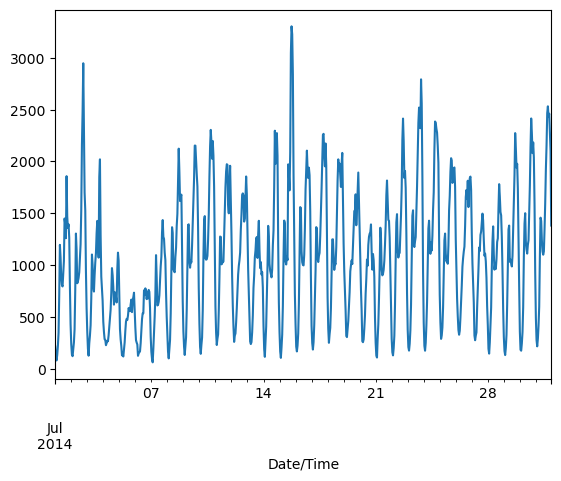

In [137]:
# Vẽ biểu đồ đường (line chart) cho dữ liệu theo giờ
# hourly_data thường là dữ liệu đã được tổng hợp theo từng giờ
# (ví dụ: số chuyến Uber theo mỗi giờ trong ngày)
hourly_data.plot(kind='line')

# Hiển thị biểu đồ ra màn hình
plt.show()

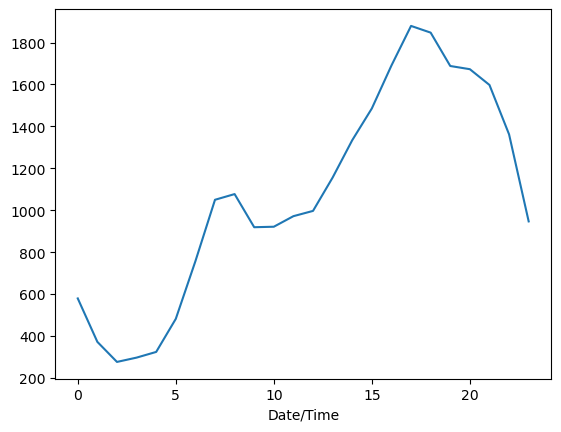

In [138]:
# Nhóm dữ liệu theo GIỜ trong ngày (0–23)
# hourly_data.index.hour sẽ trích ra phần "giờ" từ datetime index
# groupby(...).mean() → lấy giá trị trung bình cho mỗi giờ
# (ví dụ: trung bình số chuyến Uber lúc 8h qua nhiều ngày)
h = hourly_data.groupby(hourly_data.index.hour).mean()

# Vẽ biểu đồ đường thể hiện xu hướng theo từng giờ trong ngày
h.plot(kind="line")

# Hiển thị biểu đồ
plt.show()

In [139]:
# Tạo biến i để đánh dấu NGÀY THƯỜNG
# weekday(): Thứ trong tuần (0=Thứ 2, ..., 4=Thứ 6, 5=Thứ 7, 6=CN)
# <= 4  → Thứ 2 đến Thứ 6
i = hourly_data.index.weekday <= 4

# Lọc dữ liệu NGÀY THƯỜNG bằng loc[i]
# Sau đó:
# - Lấy giờ trong ngày từ index.hour
# - Group theo giờ
# - Tính giá trị trung bình cho mỗi giờ
h_week = hourly_data.loc[i].groupby(
    hourly_data.loc[i].index.hour
).mean()

# Lọc dữ liệu CUỐI TUẦN bằng cách đảo điều kiện (~i)
# Thứ 7 và Chủ nhật
# Group theo giờ và tính trung bình tương tự
h_weekend = hourly_data.loc[~i].groupby(
    hourly_data.loc[~i].index.hour
).mean()

# Gộp 2 bảng lại theo cột (axis=1)
# Cột 1: Weekday
# Cột 2: Weekend
h = pd.concat([h_week, h_weekend], axis=1)

# Đặt lại tên cột cho dễ hiểu
h.columns = ["Weekday", "Weekend"]

# In ra bảng kết quả
print(h)

               Weekday   Weekend
Date/Time                       
0           397.913043  1100.125
1           219.826087   808.875
2           160.391304   609.125
3           242.913043   451.500
4           346.565217   258.625
5           561.304348   252.750
6           922.391304   280.125
7          1290.695652   357.375
8          1279.086957   496.000
9          1008.173913   662.250
10          959.130435   812.250
11          988.695652   922.500
12         1017.086957   938.375
13         1195.869565  1040.875
14         1403.652174  1134.125
15         1583.130435  1205.125
16         1828.434783  1293.625
17         2080.478261  1301.125
18         2050.739130  1262.625
19         1900.826087  1076.625
20         1845.695652  1176.000
21         1734.217391  1205.125
22         1416.956522  1203.500
23          936.869565   974.750


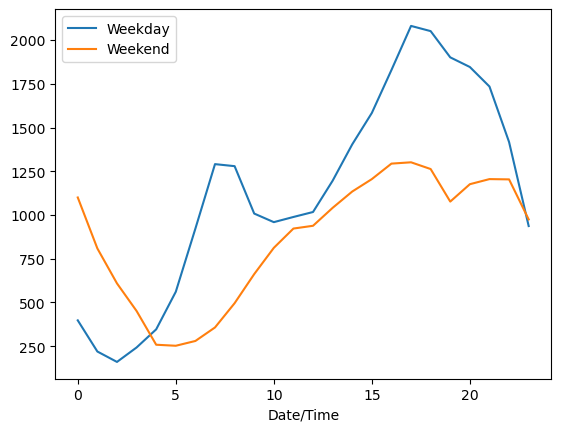

In [140]:
# Vẽ biểu đồ để quan sát sự khác biệt giữa ngày thường và cuối tuần

# plot(kind='line'):
# - Vẽ biểu đồ đường
# - Mỗi cột trong DataFrame h sẽ là một đường riêng
#   + "Weekday"  → nhu cầu Uber trung bình theo giờ vào ngày thường
#   + "Weekend"  → nhu cầu Uber trung bình theo giờ vào cuối tuần
h.plot(kind='line')

# Hiển thị biểu đồ ra màn hình
plt.show()


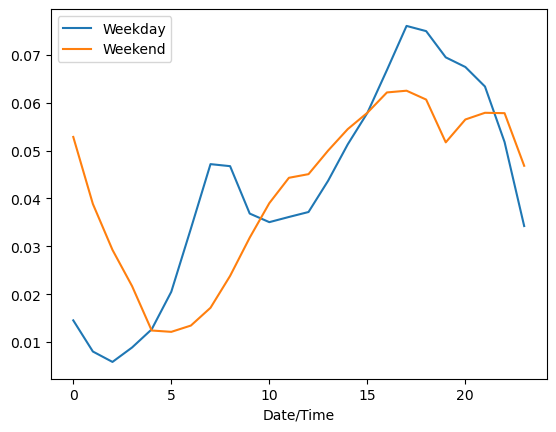

In [141]:
# Chuẩn hóa dữ liệu bằng cách chia cho tổng số chuyến trong ngày
# → Mỗi giá trị sẽ biểu diễn TỶ LỆ (%) số chuyến theo giờ,
#   thay vì số chuyến tuyệt đối

(h / h.sum()).plot(kind='line')
# h.sum():
# - Tính tổng số chuyến trong ngày
# - Thực hiện theo từng cột:
#   + Tổng chuyến Weekday
#   + Tổng chuyến Weekend
#
# h / h.sum():
# - Chia từng giá trị theo giờ cho tổng số chuyến tương ứng
# - Kết quả là tỷ lệ (0–1), thể hiện phần trăm phân bố theo giờ
#
# plot(kind='line'):
# - Vẽ biểu đồ đường cho dữ liệu đã chuẩn hóa
# - So sánh PHÂN BỐ thời gian sử dụng Uber giữa ngày thường và cuối tuần

plt.show()
# Hiển thị biểu đồ


In [142]:
from scipy.stats import ttest_ind
# Import hàm ttest_ind:
# - Thực hiện kiểm định t-test cho HAI MẪU ĐỘC LẬP
# - Dùng để so sánh trung bình của hai nhóm dữ liệu

# Hàm ttest_ind nhận vào 2 mẫu dữ liệu
# và trả về:
# - t-statistic: mức độ khác biệt giữa hai nhóm
# - p-value: xác suất để sự khác biệt này xảy ra NGẪU NHIÊN
#   (giả thuyết H0: hai nhóm giống nhau)

print(ttest_ind([100,105,110], [200,230,210]))
# Ví dụ minh họa:
# - Mẫu 1: số chuyến (hoặc tỷ lệ chuyến) của một giờ nào đó trong ngày thường
# - Mẫu 2: số chuyến tương ứng trong cuối tuần
#
# Hàm sẽ kiểm tra:
# → Trung bình hai nhóm này có khác nhau đáng kể không?


TtestResult(statistic=-11.67434463174037, pvalue=0.0003078015152715608, df=4.0)


In [143]:
# Với mỗi ngày, ta sẽ chuẩn hóa (normalize) số chuyến theo giờ bằng cách chia cho tổng số chuyến trong ngày đó
# → Kết quả là TỶ LỆ (%) số chuyến theo từng giờ trong một ngày

hourly_data_pct = hourly_data.groupby(hourly_data.index.date).apply(
    lambda x: x / x.sum()
)
# - hourly_data: chuỗi hoặc DataFrame có index là DateTime
#   (mỗi dòng tương ứng số chuyến trong 1 giờ)
#
# - hourly_data.index.date:
#   → Lấy phần NGÀY (YYYY-MM-DD), bỏ phần giờ
#
# - groupby(hourly_data.index.date):
#   → Gom các dòng theo từng ngày
#   → Mỗi nhóm = dữ liệu 24 giờ của một ngày
#
# - apply(lambda x: x / x.sum()):
#   → Với mỗi ngày:
#     + x.sum(): tổng số chuyến trong ngày đó
#     + x / x.sum(): chia từng giờ cho tổng
#   → Biến số chuyến thành TỶ LỆ trong ngày
#
# Kết quả:
# - Mỗi ngày có tổng = 1 (hoặc 100%)
# - Mỗi giá trị biểu diễn mức độ đóng góp của giờ đó trong ngày

print(hourly_data_pct)
# In ra dữ liệu đã được chuẩn hóa theo ngày

            Date/Time          
2014-07-01  2014-07-01 00:00:00    0.010175
            2014-07-01 01:00:00    0.005229
            2014-07-01 02:00:00    0.003863
            2014-07-01 03:00:00    0.006312
            2014-07-01 04:00:00    0.010505
                                     ...   
2014-07-31  2014-07-31 19:00:00    0.072449
            2014-07-31 20:00:00    0.073343
            2014-07-31 21:00:00    0.067827
            2014-07-31 22:00:00    0.062580
            2014-07-31 23:00:00    0.041203
Name: count, Length: 744, dtype: float64
